<b><u>Exercises</u></b><br>
<b>E01:</b> I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.

<b>E02:</b> BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.

In [84]:
# E01

In [111]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [112]:
words = open('names.txt', 'r').read().splitlines()

In [113]:
chars = sorted(list(set(''.join(words))))
stoi = {c:i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}

In [158]:
vocab_size = len(stoi)
block_size = 3 

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for c in w + '.':
            X.append(context)
            ix = stoi[c]
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(23)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182636, 3]) torch.Size([182636])
torch.Size([22737, 3]) torch.Size([22737])
torch.Size([22773, 3]) torch.Size([22773])


In [178]:
n_embd = 10 
n_hidden = 200 

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd))
W1 = torch.zeros((n_embd * block_size, n_hidden))
b1 = torch.zeros(n_hidden)
W2 = torch.zeros((n_hidden, vocab_size))
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

11897


In [179]:
lossi = []

In [180]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # mini-batch 
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    if i % 10000 == 0:
        print(f'{i}/{max_steps}: {loss.item()}')
    lossi.append(loss.log10().item())
    break

0/200000: 3.295837163925171


In [181]:
print(b2)
print(logits)
print(loss.item())

tensor([ 0.0088,  0.0088, -0.0037, -0.0037, -0.0006,  0.0150, -0.0037, -0.0006,
         0.0057, -0.0006, -0.0037, -0.0006, -0.0006, -0.0006,  0.0119, -0.0006,
        -0.0037, -0.0037, -0.0006, -0.0037, -0.0037, -0.0037, -0.0006, -0.0037,
        -0.0037, -0.0006, -0.0037], requires_grad=True)
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

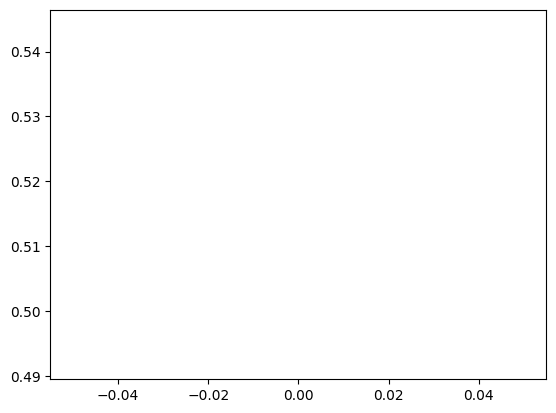

In [182]:
plt.plot(lossi)

In [183]:
# validate
@torch.no_grad()
def evaluate(split):
    X, Y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev), 
        'test': (Xte, Yte)
    }[split]
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(f"{split} loss: {loss.item()}")

evaluate('train')
evaluate('val')

train loss: 3.2915451526641846
val loss: 3.2915353775024414


In [184]:
# sample from model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    generated_word = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1 + b1
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        generated_word.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in generated_word))

cbrpzhxqtbjhqvkfkwmrpxqthtykhkcaqskejrzhnbnfqpwsyhc.
vgqeiunrzmuqptcmziivduslhggphhbmgpoinfqdqjtzsrlivwa.
vvdbquwqjehogdjaryxixfkqeupiusdbwed.
ecxiatgtlffhysflquhpqgmovdjhksyjrpmqqosozswjcojqmwycjsfrenqkpfsadlnuo.
zoebsrkoiazhrynhr.
opklhynrxph.
xqioloqbprbvbbdn.
ipyqmuitjpbvfpzpddgpycsislqwkkmcrnzazqnyjydpk.
kvwesdatimzamdtevl.
ky.
qdyctoorowooktbykomokibfcw.
zoinhzcs.
nu.
eoaiunqqeroqci.
ipjzyfbadyigluglc.
nwzyzdjokhnlhjjqsxmuadmtjhvtoyaplwuw.
xisxwrdfv.
zphtzbiuzzsrvgmknbfyntiysfgdgknmmj.
pqgcrvdhpvdafpsdvkhzkxkimtvoocjupgawjmjqjwgvhflwkewtxjrclxdctpvhgqllyuil.
hhmc.


In [185]:
W1

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)

In [186]:
W2

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)

In [187]:
b1

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

In [188]:
b2

tensor([ 0.0088,  0.0088, -0.0037, -0.0037, -0.0006,  0.0150, -0.0037, -0.0006,
         0.0057, -0.0006, -0.0037, -0.0006, -0.0006, -0.0006,  0.0119, -0.0006,
        -0.0037, -0.0037, -0.0006, -0.0037, -0.0037, -0.0037, -0.0006, -0.0037,
        -0.0037, -0.0006, -0.0037], requires_grad=True)